In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(5, 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        stretching_energy = 0.5 * (self.K[0] * del_strain[0]**2 + self.K[0] * del_strain[1]**2)
        bending_energy = 0.5 * (self.K[1] * del_strain[3]**2)
        return stretching_energy + bending_energy



In [ ]:

validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_old.npz", valid_file="output_valid.npz", n_epochs=500, lr=1e-2, init_K=jnp.array([2.0, 0.02]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Step 0    | LR: 1.000e-02  | Train: 1.83150e-04  | Valid: 1.46993e-04  | K: [2.00999965 0.02999997]
Step 10   | LR: 9.991e-03  | Train: 6.55531e-06  | Valid: 4.37759e-06  | K: [2.09457789 0.11834449]
Step 20   | LR: 9.965e-03  | Train: 1.12694e-05  | Valid: 1.18756e-05  | K: [2.12787202 0.15564705]
Step 30   | LR: 9.921e-03  | Train: 7.35368e-06  | Valid: 6.51052e-06  | K: [2.12260796 0.14412732]
Step 40   | LR: 9.859e-03  | Train: 3.45749e-06  | Valid: 3.58635e-06  | K: [2.10704242 0.12326052]
Step 50   | LR: 9.781e-03  | Train: 4.02750e-06  | Valid: 3.95817e-06  | K: [2.10074553 0.12041153]
Step 60   | LR: 9.685e-03  | Train: 3.34149e-06  | Valid: 3.36142e-06  | K: [2.10029455 0.12829035]
Step 70   | LR: 9.573e-03  | Train: 3.39870e-06  | Valid: 3.40649e-06  | K: [2.09514098 0.13067898]
Step 80   | LR: 9.446e-03  | Train: 3.28137e-06  | Valid: 3.29769e-06  | K: [2.08614243 0.12824541]
Step 90   | LR: 9.302e-03  | Train: 3.25948e-06  | Valid: 3.27419e-06  | K: [2.07809242 0.12783613]


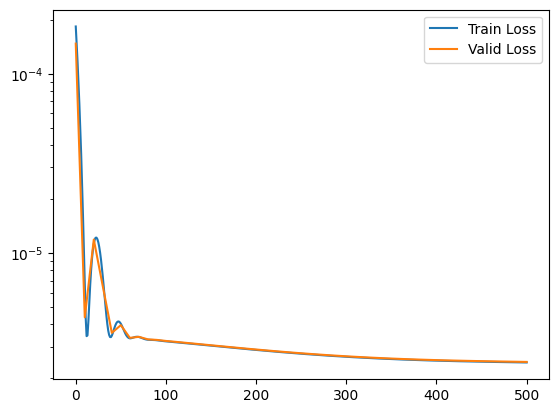

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util import TestCase

train = TestCase.from_npz("output.npz")
valid = TestCase.from_npz("output_valid.npz")
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.    0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[ 0.    0.    0.    0.    0.   -0.1   0.   -0.05]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [6]:

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [7]:
animate(valid.qs)

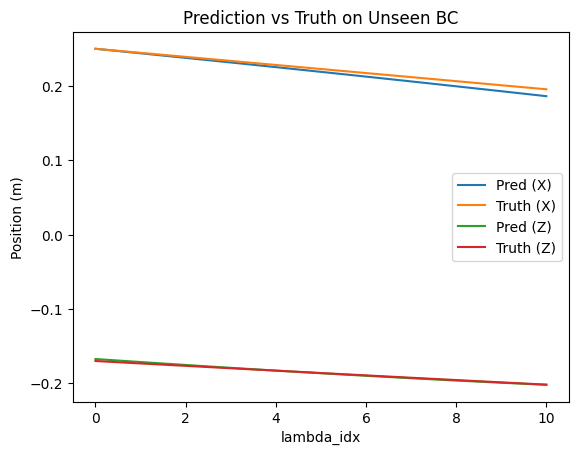

In [8]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [9]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [0.4  0.   0.05]
Validation BC:
init:  [0.5 0.  0. ]
final:  [ 0.4   0.   -0.05]


In [10]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 2.04503756e-01 -5.49553991e-05 -1.51743630e-01]


In [11]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 1.95521151e-01  6.64904575e-05 -2.01744441e-01]


In [12]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [ 0.25        0.         -0.16725347]
final position of the middle node in the prediction:  [ 0.18625346  0.         -0.20191718]
